(10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4

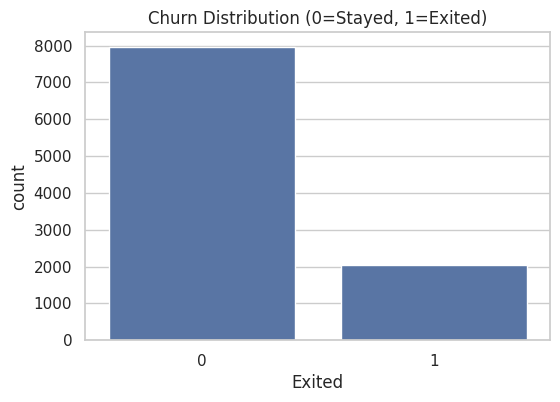

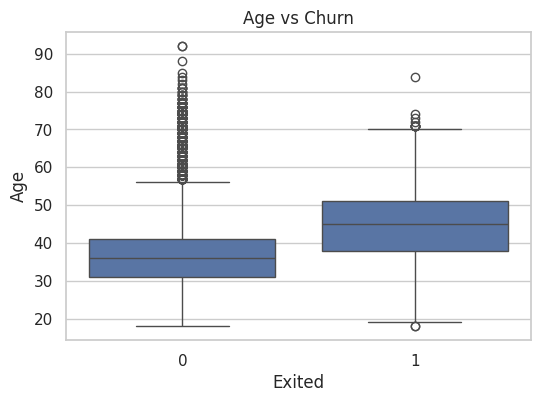

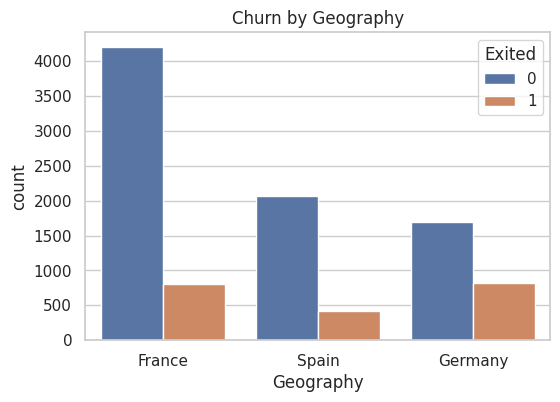

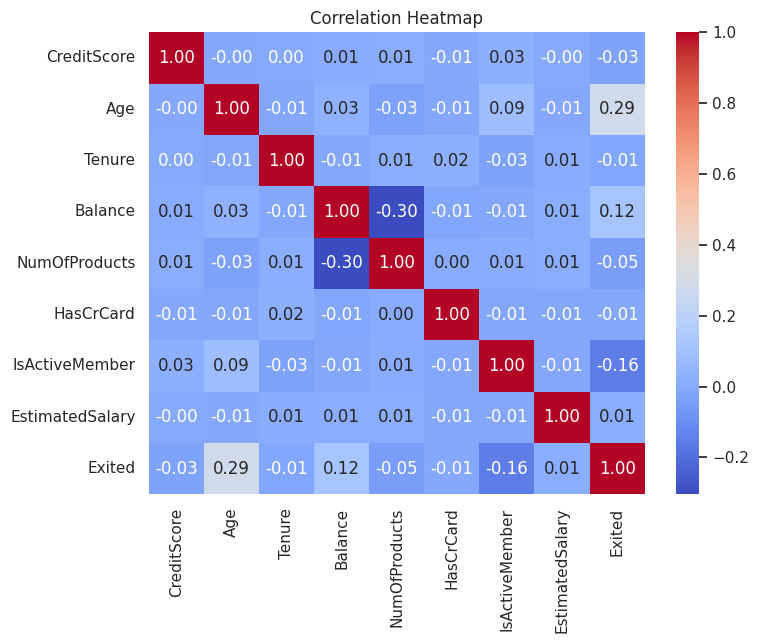


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1593
           1       0.45      0.48      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000




--- Random Forest ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000


=== MODEL COMPARISON ===
                 Model  Accuracy  F1 Score  Precision  Recall   RMSE
2        Random Forest     0.864     0.579      0.782   0.459  0.369
1        Decision Tree     0.776     0.465      0.453   0.477  0.473
0  Logistic Regression     0.805     0.229      0.586   0.143  0.442


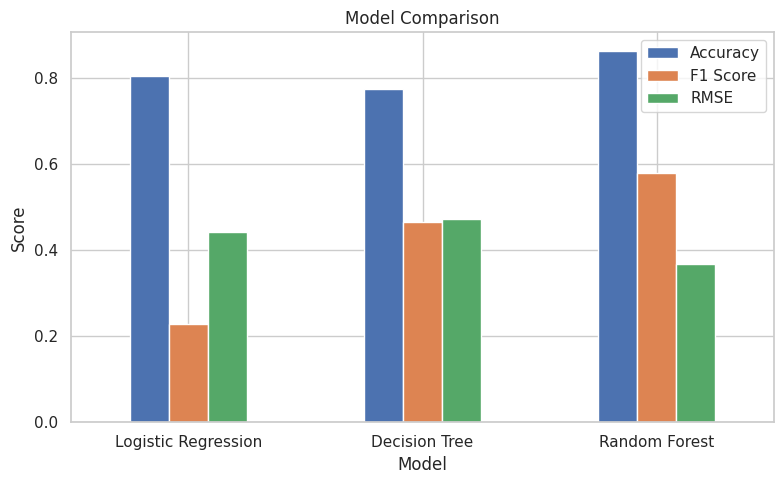

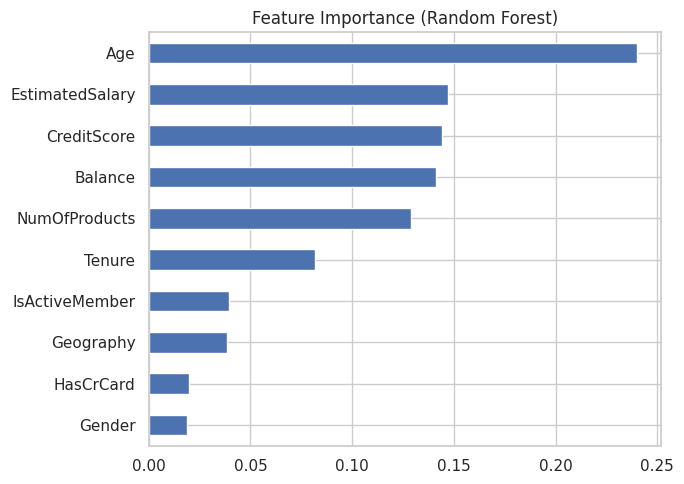

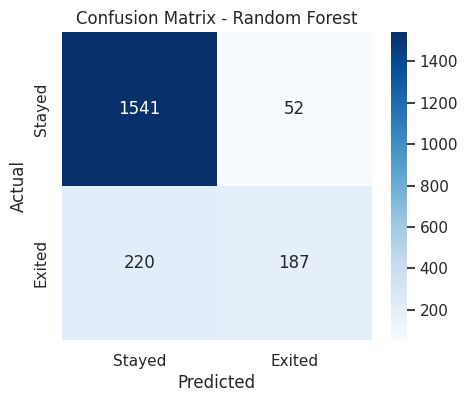

In [1]:
# -----------------------------------------------
# Bank Customer Churn Prediction - End to End ML Project
# Dataset: churn.csv (10,000 rows)
#------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report,
                              mean_squared_error)

# ------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------
df = pd.read_csv(r"churn.csv")
print(df.shape)
print(df.head())
print(df["Exited"].value_counts())

# ------------------------------------------------
# 2. EDA
# ------------------------------------------------
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution (0=Stayed, 1=Exited)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Geography")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).drop(columns=["RowNumber","CustomerId"]).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------------
# 3. PREPROCESSING
# ------------------------------------------------
# Drop irrelevant identifier columns
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Encode categorical columns
le_geo = LabelEncoder()
df["Geography"] = le_geo.fit_transform(df["Geography"])

le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

# Features and target
X = df.drop(columns=["Exited"])
y = df["Exited"]

# Train/test split (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------
# 4. MODEL TRAINING + COMPARISON
# ------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "F1 Score": round(f1, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "RMSE": round(rmse, 3)
    })

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))

# ------------------------------------------------
# 5. RESULTS COMPARISON TABLE
# ------------------------------------------------
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df.sort_values(by="F1 Score", ascending=False))

results_df.set_index("Model")[["Accuracy", "F1 Score", "RMSE"]].plot(
    kind="bar", figsize=(8,5), title="Model Comparison"
)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 6. FEATURE IMPORTANCE (Random Forest)
# ------------------------------------------------
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(7,5), title="Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 7. CONFUSION MATRIX (Best Model - Random Forest)
# ------------------------------------------------
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Exited"], yticklabels=["Stayed", "Exited"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()